# 05 — Depth-Conditioned Room Redesign with ControlNet

**Goal:** Generate a redesigned room image while using an estimated depth map as structural conditioning.

This experiment builds on the img2img baseline (Notebook 03) and depth estimation (Notebook 04). It is self-contained: it uploads the room image and recomputes depth so it does not depend on the previous notebook's runtime variables.

Run on a Colab GPU.

## 1. Install dependencies
Pillow was pinned in the original Colab runtime due to compatibility issues.

In [ ]:
!pip uninstall -y pillow -q
!pip install --no-cache-dir --force-reinstall "pillow==11.0.0" -q
!pip install -U diffusers transformers accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 21.2 MB/s eta 0:00:00


## 2. Load ControlNet and Stable Diffusion
The selected ControlNet checkpoint is trained for depth conditioning.

In [ ]:
import sys
import types
import importlib.machinery

fake_torchaudio = types.ModuleType("torchaudio")
fake_torchaudio.__spec__ = importlib.machinery.ModuleSpec("torchaudio", loader=None)
sys.modules["torchaudio"] = fake_torchaudio

import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-depth",
    torch_dtype=torch.float16
)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

print("ControlNet + SD pipeline loaded")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.45GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


...

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

ControlNet + SD pipeline loaded


## 3. Upload the room image and compute depth
This notebook currently resizes the input to 512×512. That may distort non-square rooms; consider preserving aspect ratio in a future experiment if composition changes are problematic.

Saving room1.jpg to room1.jpg


config.json:   0%|          | 0.00/9.88k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  490MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  490MB            

model.safetensors: downloading bytes:           |  0.00B            

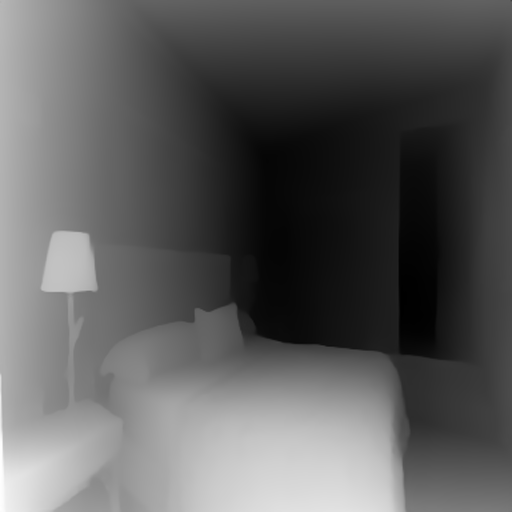

In [ ]:
from google.colab import files
import io
from PIL import Image
from transformers import pipeline as hf_pipeline

uploaded = files.upload()
filename = list(uploaded.keys())[0]
room_image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB").resize((512, 512))

depth_estimator = hf_pipeline(
    task="depth-estimation",
    model="Intel/dpt-hybrid-midas",
    device=0
)
depth_result = depth_estimator(room_image)
depth_map = depth_result["depth"].resize((512, 512))

depth_map

## 4. Generate the first depth-conditioned result
The prompt should describe the intended redesign. Save this as the first ControlNet result for evaluation.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (86 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', high - end interior photography , 8 k resolution .']


  0%|          | 0/30 [00:00<?, ?it/s]

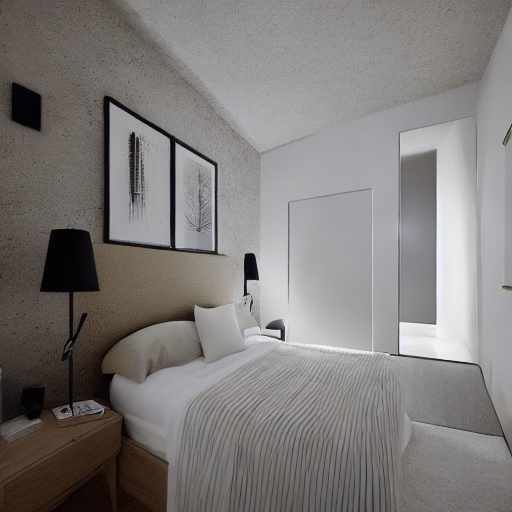

In [ ]:
generation_prompt = "A modern minimalist bedroom featuring soft beige walls and light oak floors. A low-profile light wood platform bed with crisp white bedding is centered on the wall, flanked by two matching light wood floating nightstands topped with modern slim table lamps. A sleek white wardrobe and simple light wood desk sit cleanly against adjacent walls. Bright, airy, uncluttered aesthetic, natural light, high-end interior photography, 8k resolution."

result_image = pipe(
    prompt=generation_prompt,
    image=depth_map,
    guidance_scale=7.5,
    num_inference_steps=30
).images[0]

result_image.save("controlnet_output.png")
result_image

## 5. Run a prompt refinement experiment
This second pass adds emphasis on visible wardrobe and door details. Compare it with the first output using the same input image and settings.

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', high - end interior photography , 8 k resolution . wardrobe and door clearly visible , wooden door with visible panel details .']


  0%|          | 0/30 [00:00<?, ?it/s]

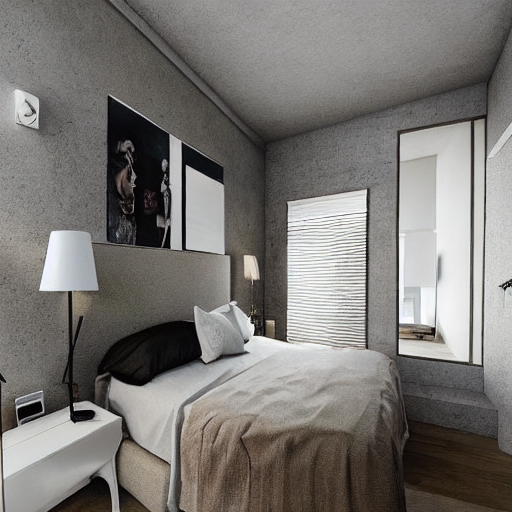

In [ ]:
result_image_v2 = pipe(
    prompt=generation_prompt + " Wardrobe and door clearly visible, wooden door with visible panel details.",
    image=depth_map,
    guidance_scale=7.5,
    num_inference_steps=30,
    controlnet_conditioning_scale=1.3
).images[0]

result_image_v2.save("controlnet_output_v2.png")
result_image_v2

## Compare with the img2img baseline
Use the same source image and a comparable design prompt, then compare:
- structural similarity to the original room
- furniture and color adherence
- visibility of doors and windows
- visual artifacts and overall realism

Keep a record of the prompt, inference steps, guidance scale, and conditioning scale for each experiment.